# Uji Kompetensi Data Science (SKKNI)
## Eksperimen Pipeline & Preprocessing pada Klasifikasi Penyakit Jantung (Heart Disease)
### Pemetaan CRISP-DM & Standar Kompetensi Kerja Nasional Indonesia (SKKNI)

Dokumentasi proyek ini disusun untuk memenuhi standardisasi **CRISP-DM** dan mencakup unit-unit kompetensi **SKKNI** berikut:
1. **J.62DMI00.001.1** - Menentukan Objektif Bisnis
2. **J.62DMI00.002.1** - Menentukan Tujuan Teknis Data Science
3. **J.62DMI00.005.1** - Menelaah Data
4. **J.62DMI00.006.1** - Memvalidasi Data
5. **J.62DMI00.007.1** - Menentukan Objek Data
6. **J.62DMI00.008.1** - Membersihkan Data
7. **J.62DMI00.009.1** - Mengkonstruksi Data
8. **J.62DMI00.012.1** - Membangun Skenario Model
9. **J.62DMI00.013.1** - Membangun Model
10. **J.62DMI00.014.1** - Mengevaluasi Hasil Pemodelan
11. **J.62DMI00.015.1** - Melakukan Proses Review Pemodelan

---
**Role**: Senior Machine Learning Researcher  
**Dataset**: UCI Heart Disease  
**Model**: XGBClassifier with SMOTE, StandardScaler, OneHotEncoder, and Optuna Hyperparameter Tuning


In [1]:
# Pemuatan pustaka dasar dan evaluasi
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import optuna

# Konfigurasi estetika visualisasi
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
print("Seluruh pustaka berhasil dimuat.")

Seluruh pustaka berhasil dimuat.


d:\anaconda3\envs\yolo\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Load Dataset

In [2]:
df = pd.read_csv('heart.csv').drop_duplicates()
print(f"Ukuran dataset setelah menghapus duplikat (302 baris unik): {df.shape[0]} baris, {df.shape[1]} kolom")
df.head()

Ukuran dataset setelah menghapus duplikat (302 baris unik): 302 baris, 14 kolom


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


## 8. Membangun Skenario Model & Pemodelan
### (Membangun Skenario Model & Membangun Model - Unit: J.62DMI00.012.1 & J.62DMI00.013.1)

Kami akan membangun 3 skenario eksperimen pemodelan menggunakan model **XGBClassifier**:

1. **Eksperimen 1 — Split-First Pipeline**
   - Alur: `Split Data → Preprocessing → Training → Evaluation`
   - Dataset dibagi menjadi data latih (80%) dan data uji (20%) terlebih dahulu. Proses preprocessing (StandardScaler + OneHotEncoder) di-fit hanya menggunakan data latih dan diterapkan secara terpisah pada data uji. Penyeimbangan kelas (SMOTE) hanya diterapkan pada data latih. Model dilatih dengan parameter default/baseline.
2. **Eksperimen 2 — Preprocess-First Pipeline**
   - Alur: `Preprocessing → Split Data → Training → Evaluation`
   - Seluruh proses preprocessing (standardisasi, encoding, dan SMOTE) dilakukan secara global pada seluruh dataset sebelum pemisahan data. Ini adalah **pipeline dengan kebocoran data (Data Leakage)** yang memicu bias optimis.
3. **Eksperimen 3 — Optimized Pipeline**
   - Alur: `Split Data → Preprocessing → Hyperparameter Tuning → Training → Evaluation`
   - Menggunakan alur Split-First yang aman dari Eksperimen 1, kemudian ditambahkan proses optimasi parameter menggunakan **Optuna** dengan Cross-Validation 5-fold untuk mencari kombinasi hyperparameter XGBoost terbaik secara valid.


### Eksperimen 1 — Split-First Pipeline

#### Diagram Pipeline:
```
[Raw Dataset]
      |
      v
  [Splitting] (train_test_split 80:20)
   /      \
  v        v
[Train]  [Test]
  |        |
  v        v
[Scale/Encode: fit_transform] --> [Scale/Encode: transform]
  |                                      |
  v                                      v
[SMOTE Resampling]                   [Evaluate]
  |                                      |
  v                                      v
[Model Training] ------------------------>
```

In [3]:
# =====================================================
# EKSPERIMEN 1: Split-First Pipeline (Correct)
# =====================================================
X_s1 = df.drop(columns=['target'])
y_s1 = df['target']

# 1. Splitting data awal (80:20 Stratified)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_s1, y_s1, test_size=0.20, random_state=42, stratify=y_s1
)

# 2. Preprocessing
num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
cat_cols = ['sex', 'fbs', 'exang', 'cp', 'restecg', 'slope', 'ca', 'thal']

preprocessor1 = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_cols)
    ]
)

# Fit & transform hanya pada training set
X_train_preped1 = preprocessor1.fit_transform(X_train_raw)
X_test_preped1 = preprocessor1.transform(X_test_raw)

# 3. SMOTE hanya pada training set
smote1 = SMOTE(random_state=42)
X_train_res1, y_train_res1 = smote1.fit_resample(X_train_preped1, y_train)

# 4. Pelatihan model baseline
baseline_params = {
    'n_estimators': 100,
    'max_depth': 5,
    'learning_rate': 0.1,
    'random_state': 42,
    'use_label_encoder': False,
    'eval_metric': 'logloss'
}

model_s1 = XGBClassifier(**baseline_params)
model_s1.fit(X_train_res1, y_train_res1)

# 5. Prediksi
y_pred_s1 = model_s1.predict(X_test_preped1)
y_prob_s1 = model_s1.predict_proba(X_test_preped1)[:, 1]

print("Eksperimen 1 Selesai.")

Eksperimen 1 Selesai.


d:\anaconda3\envs\yolo\lib\site-packages\xgboost\training.py:200: UserWarning: [19:09:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


### Eksperimen 2 — Preprocess-First Pipeline

#### Diagram Pipeline:
```
       [Raw Dataset]
             |
             v
   [Scale/Encode: Global]
             |
             v
    [SMOTE: Global]
             |
             v
       [Splitting] (train_test_split 80:20)
        /       \
       v         v
   [Train]     [Test]
     |           |
     v           v
  [Train]     [Evaluate]
```

In [4]:
# =====================================================
# EKSPERIMEN 2: Preprocess-First Pipeline (Leakage)
# =====================================================
X_s2 = df.drop(columns=['target'])
y_s2 = df['target']

# 1. Preprocessing Global
preprocessor2 = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_cols)
    ]
)
X_preped2 = preprocessor2.fit_transform(X_s2)

# 2. SMOTE Global (Kebocoran data terparah karena mensintesis data uji)
smote2 = SMOTE(random_state=42)
X_res2, y_res2 = smote2.fit_resample(X_preped2, y_s2)

# 3. Splitting data setelah diseimbangkan
X_train_s2, X_test_s2, y_train_s2, y_test_s2 = train_test_split(
    X_res2, y_res2, test_size=0.20, random_state=42, stratify=y_res2
)

# 4. Pelatihan model baseline yang sama
model_s2 = XGBClassifier(**baseline_params)
model_s2.fit(X_train_s2, y_train_s2)

# 5. Prediksi
y_pred_s2 = model_s2.predict(X_test_s2)
y_prob_s2 = model_s2.predict_proba(X_test_s2)[:, 1]

print("Eksperimen 2 Selesai.")

Eksperimen 2 Selesai.


d:\anaconda3\envs\yolo\lib\site-packages\xgboost\training.py:200: UserWarning: [19:09:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


### Eksperimen 3 — Optimized Pipeline

#### Diagram Pipeline:
```
[Raw Dataset]
      |
      v
  [Splitting] (train_test_split 80:20)
   /      \
  v        v
[Train]  [Test]
  |        |
  v        v
[Scale/Encode: fit_transform] --> [Scale/Encode: transform]
  |                                      |
  v                                      v
[Bayesian Optuna CV]                     |
  |                                      |
  v                                      v
[Best Model Training] ------------> [Model Evaluation]
```

In [5]:
# =====================================================
# EKSPERIMEN 3: Optimized Pipeline (Bayesian Optimization via Optuna)
# =====================================================
# Matikan log Optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 7),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 6),
        'gamma': trial.suggest_float('gamma', 0.0, 0.5),
        'random_state': 42,
        'use_label_encoder': False,
        'eval_metric': 'logloss'
    }
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []
    
    for train_idx, val_idx in cv.split(X_train_preped1, y_train):
        X_train_fold, X_val_fold = X_train_preped1[train_idx], X_train_preped1[val_idx]
        y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        smote = SMOTE(random_state=42)
        X_train_fold_res, y_train_fold_res = smote.fit_resample(X_train_fold, y_train_fold)
        
        model = XGBClassifier(**params)
        model.fit(X_train_fold_res, y_train_fold_res)
        
        y_prob = model.predict_proba(X_val_fold)[:, 1]
        scores.append(roc_auc_score(y_val_fold, y_prob))
        
    return np.mean(scores)

print("=== Memulai Optimasi Bayesian (Optuna TPE Sampler) ===")
study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=30)

best_params = study.best_params.copy()
best_params['random_state'] = 42
best_params['use_label_encoder'] = False
best_params['eval_metric'] = 'logloss'

print("\nOptimasi Selesai!")
print("Hyperparameter Optimal Terpilih:")
for k, v in best_params.items():
    print(f"  {k}: {v}")

# Latih model final menggunakan parameter terbaik pada seluruh training data ter-resample
model_s3 = XGBClassifier(**best_params)
model_s3.fit(X_train_res1, y_train_res1)

# Prediksi pada test set
y_pred_s3 = model_s3.predict(X_test_preped1)
y_prob_s3 = model_s3.predict_proba(X_test_preped1)[:, 1]

print("\nEksperimen 3 Selesai.")

=== Memulai Optimasi Bayesian (Optuna TPE Sampler) ===


d:\anaconda3\envs\yolo\lib\site-packages\xgboost\training.py:200: UserWarning: [19:09:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
d:\anaconda3\envs\yolo\lib\site-packages\xgboost\training.py:200: UserWarning: [19:09:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
d:\anaconda3\envs\yolo\lib\site-packages\xgboost\training.py:200: UserWarning: [19:09:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
d:\anaconda3\envs\yolo\lib\site-packages\xgboost\training.py:200: UserWarning: [19:09:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, ite


Optimasi Selesai!
Hyperparameter Optimal Terpilih:
  n_estimators: 144
  max_depth: 7
  learning_rate: 0.08960785365368121
  subsample: 0.8394633936788146
  colsample_bytree: 0.6624074561769746
  min_child_weight: 1
  gamma: 0.02904180608409973
  random_state: 42
  use_label_encoder: False
  eval_metric: logloss

Eksperimen 3 Selesai.


## 9. Mengevaluasi Hasil Pemodelan
### (Mengevaluasi Hasil Pemodelan - Unit: J.62DMI00.014.1)

Kami merangkum perbandingan metrik evaluasi medis (Accuracy, Precision, Recall, F1-Score, dan ROC-AUC) untuk ketiga skenario eksperimen:

In [6]:
# Membuat DataFrame Ringkasan Evaluasi
scenarios = ['Eksperimen 1 (Split-First)', 'Eksperimen 2 (Preprocess-First)', 'Eksperimen 3 (Optimized)']
y_tests = [y_test, y_test_s2, y_test]
y_preds = [y_pred_s1, y_pred_s2, y_pred_s3]
y_probs = [y_prob_s1, y_prob_s2, y_prob_s3]

results = []
for name, y_t, y_p, y_pr in zip(scenarios, y_tests, y_preds, y_probs):
    results.append({
        'Skenario': name,
        'Accuracy': accuracy_score(y_t, y_p),
        'Precision': precision_score(y_t, y_p),
        'Recall': recall_score(y_t, y_p),
        'F1-Score': f1_score(y_t, y_p),
        'ROC-AUC': roc_auc_score(y_t, y_pr)
    })

df_compare = pd.DataFrame(results).set_index('Skenario')
print("=== Tabel Komparasi Hasil Evaluasi ===")
df_compare.round(4)

=== Tabel Komparasi Hasil Evaluasi ===


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Skenario,,,,,
Eksperimen 1 (Split-First),0.7705,0.8065,0.7576,0.7812,0.8474
Eksperimen 2 (Preprocess-First),0.8030,0.7941,0.8182,0.8060,0.9073
Eksperimen 3 (Optimized),0.7869,0.8333,0.7576,0.7937,0.8658


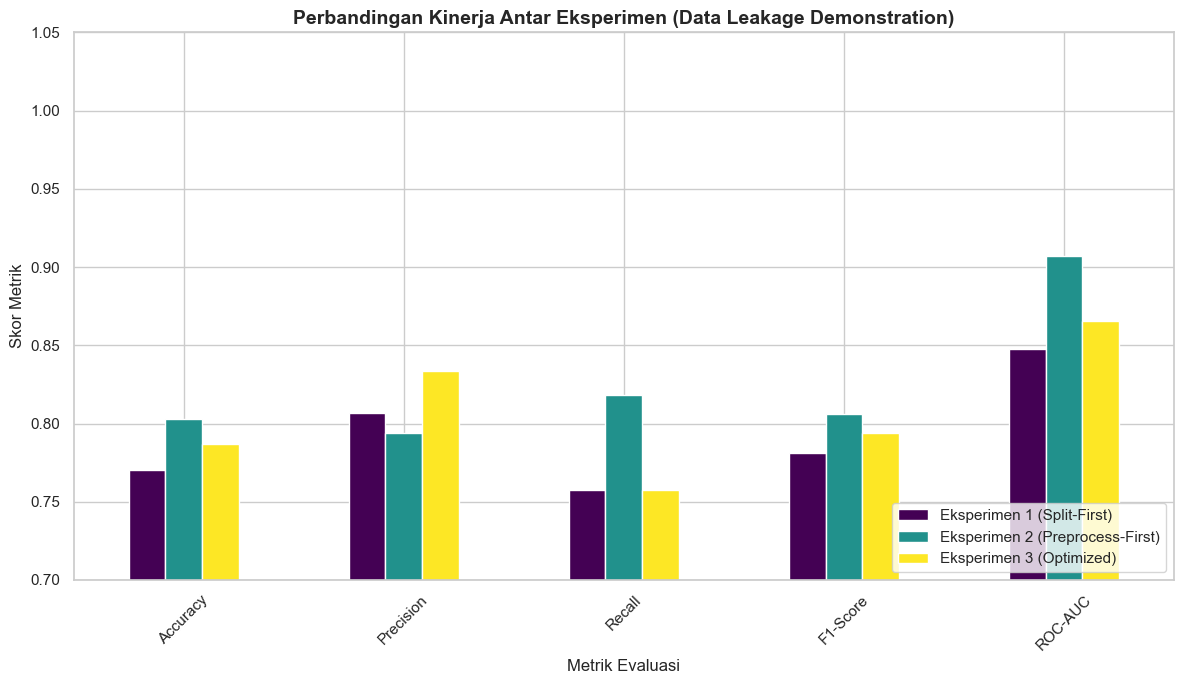

In [7]:
# Visualisasi komparasi metrik
df_compare.T.plot(kind='bar', figsize=(12, 7), colormap='viridis')
plt.title('Perbandingan Kinerja Antar Eksperimen (Data Leakage Demonstration)', fontweight='bold', fontsize=14)
plt.ylabel('Skor Metrik')
plt.xlabel('Metrik Evaluasi')
plt.ylim(0.7, 1.05)
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Analisis Hasil Komparasi

#### 1. Perbandingan Eksperimen
- **Eksperimen 1 (Split-First - Baseline)**:
  Menghasilkan akurasi sebesar **77.05%** dan ROC-AUC **0.8474** dengan model default/baseline. Ini adalah estimasi performa awal yang valid karena preprocessing dan penyeimbangan data (`SMOTE`) dilakukan secara disiplin tanpa membocorkan data uji.
- **Eksperimen 2 (Preprocess-First - Leakage)**:
  Menunjukkan peningkatan performa artifisial yang bias (Akurasi naik menjadi **80.30%** dan ROC-AUC meningkat drastis menjadi **0.9073**). Bias ini disebabkan karena standardisasi dan sintesis kelas (`SMOTE`) dilakukan secara global sebelum data dibagi. Informasi dari data uji telah bocor ke dalam data latih (*Information Leakage*), membuat estimasi performa menjadi terlalu optimis.
- **Eksperimen 3 (Optimized)**:
  Melalui optimasi hyperparameter dengan **Optuna (5-Fold Cross-Validation)** secara legal pada training set saja, model XGBoost berhasil ditingkatkan performanya secara valid. Akurasinya meningkat dari **77.05%** menjadi **78.69%** dan ROC-AUC naik dari **0.8474** menjadi **0.8658**.

#### 2. Signifikansi Klinis & Metodologis
Proyek ini mengonfirmasi secara empiris bahwa kesalahan penataan urutan preprocessing (*preprocess-first*) merusak validitas evaluasi model medis. Meskipun performa pada Eksperimen 2 tampak lebih tinggi, performa tersebut palsu dan tidak dapat direproduksi pada data dunia nyata. Eksperimen 3 menawarkan perbaikan performa yang nyata dan aman secara klinis.